# Шаг 10 — Ансамбль: ALS + SVD + NCF

Объединяем три лучшие модели проекта в взвешенный ансамбль.
Цель — улучшить top-N метрики относительно лучшей одиночной модели (ALS).

## Стратегия ансамблирования

Модели выбраны по принципу разнообразия семейств — каждая улавливает разные паттерны:

| Модель | Семейство | NDCG@10 (test) | Сильная сторона |
|--------|-----------|:--------------:|-----------------|
| ALS | Implicit MF | 0.2895 | Лучший по всем top-N метрикам |
| SVD | Explicit MF | 0.2005 | Другая оптимизация (explicit рейтинги) |
| NCF | Neural | 0.0868 | Нелинейные взаимодействия user × item |

KNN (NDCG@10 = 0.057) и LightGBM (0.067) не включены — слишком слабы,
добавят шум без значимого сигнала.

**Метод:** взвешенное усреднение score-векторов перед ранжированием.
Веса подбираются Optuna по NDCG@10 на val (20 trials, Dirichlet-сэмплинг).

## Методологические замечания

**Единый порог релевантности — 3.5** (как у SVD / NCF).
ALS обучен при пороге 4.0 (implicit feedback), но для оценки ансамбля
используем 3.5 — более широкий ground truth, стабильнее метрики.

**Score-нормализация перед слиянием.**
Шкалы разных моделей несовместимы: SVD и NCF выдают [0.5, 5.0],
ALS — произвольные вещественные числа. Каждый score-вектор нормализуется
в [0, 1] через min-max перед взвешиванием.

**Optuna оптимизирует только на val.**
Test используется однократно для финальной оценки — без утечки через подбор весов.

## Место в проекте

```
notebooks/
├── 08_model_implicit_als.ipynb   ALS
├── 09_model_ncf.ipynb            NCF
├── 10_ensemble_als_svd_ncf.ipynb ◄── вы здесь
└── 11_final_comparison.ipynb
```

## Артефакты (сохраняются в `models/`)

| Файл | Описание |
|------|---------|
| `ensemble_weights.json` | Оптимальные веса ALS / SVD / NCF |
| `ensemble_metrics.json` | Top-N метрики ансамбля на test |
| `ablation_results.parquet` | Результаты ablation study |


## 0. Импорты и настройки


In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import sys
sys.path.append('..')

from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

import tensorflow as tf
import optuna
import optuna.visualization as ov
from implicit.als import AlternatingLeastSquares
from surprise import SVD

from src.utils import SEED, set_seeds, set_seeds_tf
from src.data_io import load_splits, load_features, load_id_maps, load_tag_features
from src.metrics import (
    evaluate_topn, build_ground_truth,
    ndcg_at_k, precision_at_k, recall_at_k, hit_rate_at_k, coverage,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.get_logger().setLevel('ERROR')
set_seeds()

MODELS_DIR    = Path('../models')
PROCESSED_DIR = Path('../data/processed')

RELEVANCE_THRESHOLD = 3.5
K_PRIMARY           = 10
K_VALUES            = (5, 10, 20)

print(f"SEED                = {SEED}")
print(f"TensorFlow          = {tf.__version__}")
print(f"Optuna              = {optuna.__version__}")
print(f"relevance threshold = {RELEVANCE_THRESHOLD}")


SEED                = 29042005
TensorFlow          = 2.18.0
Optuna              = 4.2.1
relevance threshold = 3.5


## 1. Загрузка данных и артефактов моделей

Загружаем обученные модели из шагов 5, 8, 9 и общие структуры данных.
Все три модели должны быть сохранены в `models/` до запуска этого ноутбука.


In [2]:
# ── Данные ──────────────────────────────────────────────────────────────────
splits           = load_splits()
train, val, test = splits['train'], splits['val'], splits['test']

features         = load_features()
movies_enriched  = features['movies_enriched']

maps             = load_id_maps()
user_id_map      = maps['user_id_map']
movie_id_map     = maps['movie_id_map']
inv_user_id_map  = maps['inv_user_id_map']
inv_movie_id_map = maps['inv_movie_id_map']

n_users  = len(user_id_map)
n_movies = len(movie_id_map)

train_val = pd.concat([train, val], ignore_index=True)

print(f"users={n_users}, movies={n_movies}")
print(f"train={len(train):,}, val={len(val):,}, test={len(test):,}")


users=610, movies=5446
train=68,829, val=12,289, test=11,728


In [3]:
# ── Загрузка моделей ─────────────────────────────────────────────────────────
final_svd = joblib.load(MODELS_DIR / 'svd_model.pkl')
final_als = joblib.load(MODELS_DIR / 'als_model.pkl')
final_ncf = tf.keras.models.load_model(MODELS_DIR / 'ncf_model.keras')

print("SVD   модель загружена:", type(final_svd).__name__)
print("ALS   модель загружена:", type(final_als).__name__)
print("NCF   модель загружена:", final_ncf.name)

# ── Загрузка метрик для итоговой таблицы сравнения ──────────────────────────
with open(MODELS_DIR / 'popularity_metrics.json',  'r', encoding='utf-8') as f:
    pop_metrics = json.load(f)
with open(MODELS_DIR / 'popularity_params.json',   'r', encoding='utf-8') as f:
    pop_params_saved = json.load(f)
with open(MODELS_DIR / 'svd_metrics.json',         'r', encoding='utf-8') as f:
    svd_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'knn_metrics.json',         'r', encoding='utf-8') as f:
    knn_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'lightgbm_metrics.json',    'r', encoding='utf-8') as f:
    lgbm_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'als_metrics.json',         'r', encoding='utf-8') as f:
    als_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'ncf_metrics.json',         'r', encoding='utf-8') as f:
    ncf_metrics_loaded = json.load(f)

print("\nМетрики всех моделей загружены.")


SVD   модель загружена: SVD
ALS   модель загружена: AlternatingLeastSquares
NCF   модель загружена: NeuMF

Метрики всех моделей загружены.


## 2. Подготовка вспомогательных структур для ALS

ALS работает со sparse CSR-матрицей взаимодействий и id-маппингами.
Воссоздаём те же структуры, что использовались в шаге 8.


In [4]:
# ── Матрицы взаимодействий для ALS ──────────────────────────────────────────
# Для inference нам нужна маска «просмотренных» — все фильмы из train+val
all_seen_train_val_ui = sparse.csr_matrix(
    (np.ones(len(train_val), dtype=np.float32),
     (train_val['user_idx'].values, train_val['movie_idx'].values)),
    shape=(n_users, n_movies),
)
# Для val-оценки ансамбля — маска только train
all_seen_train_ui = sparse.csr_matrix(
    (np.ones(len(train), dtype=np.float32),
     (train['user_idx'].values, train['movie_idx'].values)),
    shape=(n_users, n_movies),
)

print(f"all_seen_train_ui (train):     {all_seen_train_ui.nnz:,} interactions")
print(f"all_seen_train_val_ui (full):  {all_seen_train_val_ui.nnz:,} interactions")


all_seen_train_ui (train):     68,829 interactions
all_seen_train_val_ui (full):  81,118 interactions


## 3. Функции получения score-векторов

Для ансамблирования каждая модель должна вернуть **полный вектор scores**
по всем фильмам-кандидатам для заданного пользователя — без ранжирования.
Каждая модель возвращает scores в своей шкале; нормализация выполняется на следующем шаге.


In [5]:
def get_svd_scores(model, user_id_raw: int, candidate_movies: np.ndarray) -> np.ndarray:
    scores = np.array([
        model.predict(uid=user_id_raw, iid=mid).est
        for mid in candidate_movies
    ], dtype=np.float32)
    return scores


def get_als_scores(model, user_id_raw: int, candidate_movies: np.ndarray,
                    seen_ui_csr) -> np.ndarray:
    uidx = user_id_map[user_id_raw]
    u_vec = model.user_factors[uidx]                       # (factors,)
    candidate_idx = np.array([movie_id_map[m] for m in candidate_movies
                               if m in movie_id_map], dtype=np.int32)

    # Строим маппинг кандидат → индекс в candidate_movies
    mid_to_pos = {m: i for i, m in enumerate(candidate_movies)}

    scores = np.zeros(len(candidate_movies), dtype=np.float32)
    valid_mask = np.array([m in movie_id_map for m in candidate_movies])
    if valid_mask.any():
        i_factors = model.item_factors[candidate_idx]      # (n_cand, factors)
        raw_scores = i_factors @ u_vec                     # (n_cand,)
        # Раскладываем обратно по позициям
        positions = np.array([mid_to_pos[m] for m in candidate_movies
                               if m in movie_id_map])
        scores[positions] = raw_scores.astype(np.float32)
    return scores


def get_ncf_scores(model, user_id_raw: int, candidate_movies: np.ndarray,
                    batch_size: int = 4096) -> np.ndarray:

    uidx = user_id_map[user_id_raw]
    cand_idx = np.array([movie_id_map.get(m, 0) for m in candidate_movies],
                         dtype=np.int32)
    users_arr = np.full(len(cand_idx), uidx, dtype=np.int32)
    scores = model.predict(
        [users_arr, cand_idx],
        batch_size=batch_size,
        verbose=0,
    ).flatten().astype(np.float32)

    # Фильмы без маппинга получают -inf
    unknown = np.array([m not in movie_id_map for m in candidate_movies])
    scores[unknown] = -np.inf
    return scores


def minmax_normalize(scores: np.ndarray) -> np.ndarray:
    finite_mask = np.isfinite(scores)
    if not finite_mask.any():
        return np.zeros_like(scores)
    s_min = scores[finite_mask].min()
    s_max = scores[finite_mask].max()
    if s_max - s_min < 1e-9:
        out = np.zeros_like(scores, dtype=np.float32)
        out[finite_mask] = 0.5
        return out
    out = np.where(finite_mask, (scores - s_min) / (s_max - s_min), 0.0)
    return out.astype(np.float32)


print("Score-функции определены.")


Score-функции определены.


## 4. Функция ансамблевых рекомендаций

Алгоритм для каждого пользователя:
1. Получить score-вектор от каждой модели по непросмотренным фильмам
2. Нормализовать каждый вектор в [0, 1] через min-max
3. Взвешенная сумма: `score = w_als·s_als + w_svd·s_svd + w_ncf·s_ncf`
4. Сортировать по убыванию → взять топ-K

Нормализация критична: без неё ALS с большими по модулю значениями
будет доминировать независимо от весов.


In [6]:
def ensemble_recommend(
    user_ids_raw,
    seen_df,
    all_movies,
    svd_model,
    als_model,
    ncf_model,
    seen_ui_csr,
    w_als: float = 0.5,
    w_svd: float = 0.35,
    w_ncf: float = 0.15,
    k: int = 20,
    ncf_batch: int = 4096,
):
    """
    Взвешенный ансамбль ALS + SVD + NCF.

    Parameters
    ----------
    user_ids_raw : iterable[int]  — raw userId-ы
    seen_df      : pd.DataFrame   — train (или train+val) для маски просмотренных
    all_movies   : np.ndarray     — кандидатный пул фильмов
    w_als, w_svd, w_ncf : float   — веса (не обязаны суммироваться в 1;
                                     нормализуем внутри)
    k            : int            — топ-K рекомендаций

    Returns
    -------
    dict[int, list[int]]  — {userId: [movieId, ...]}
    """
    # Нормализуем веса
    total_w = w_als + w_svd + w_ncf
    w_als /= total_w
    w_svd /= total_w
    w_ncf /= total_w

    seen_by_user = seen_df.groupby('userId')['movieId'].apply(set).to_dict()
    all_movies   = np.asarray(all_movies)

    recommendations = {}

    for uid in user_ids_raw:
        seen       = seen_by_user.get(uid, set())
        candidates = all_movies[~np.isin(all_movies, list(seen))]
        if len(candidates) == 0:
            recommendations[uid] = []
            continue

        # Scores от каждой модели
        s_als = get_als_scores(als_model, uid, candidates, seen_ui_csr)
        s_svd = get_svd_scores(svd_model, uid, candidates)
        s_ncf = get_ncf_scores(ncf_model, uid, candidates, batch_size=ncf_batch)

        # Min-max нормализация
        s_als_n = minmax_normalize(s_als)
        s_svd_n = minmax_normalize(s_svd)
        s_ncf_n = minmax_normalize(s_ncf)

        # Взвешенная сумма
        ensemble_scores = w_als * s_als_n + w_svd * s_svd_n + w_ncf * s_ncf_n

        top_k_idx = np.argsort(-ensemble_scores)[:k]
        recommendations[uid] = candidates[top_k_idx].tolist()

    return recommendations


print("Функция ensemble_recommend определена.")


Функция ensemble_recommend определена.


## 5. Базовый ансамбль (равные веса — точка отсчёта)

Проверяем ансамбль с `w_als = w_svd = w_ncf = 1/3` на val.
Это нижняя планка для Optuna — оптимизация весов должна её улучшить.


In [7]:
val_ground_truth   = build_ground_truth(val, relevance_threshold=RELEVANCE_THRESHOLD)
val_users_for_eval = list(val_ground_truth.keys())
all_movies_train   = train['movieId'].unique()

print(f"Пользователей в val с GT (>={RELEVANCE_THRESHOLD}): {len(val_users_for_eval)}")
print(f"Кандидатный пул (train): {len(all_movies_train)} фильмов")

print("\nБазовый ансамбль (равные веса 1/3 каждой)...")
t0 = time.time()
baseline_val_recs = ensemble_recommend(
    val_users_for_eval, train, all_movies_train,
    svd_model=final_svd,
    als_model=final_als,
    ncf_model=final_ncf,
    seen_ui_csr=all_seen_train_ui,
    w_als=1/3, w_svd=1/3, w_ncf=1/3,
    k=K_PRIMARY,
)
baseline_eval_time = time.time() - t0

baseline_val_metrics = evaluate_topn(
    baseline_val_recs, val_ground_truth,
    ks=(K_PRIMARY,), all_items=all_movies_train,
)
print(f"Готово за {baseline_eval_time:.1f} с")
print(f"Базовый ансамбль val (равные веса):")
print(json.dumps(baseline_val_metrics, indent=2))


Пользователей в val с GT (>=3.5): 114
Кандидатный пул (train): 5446 фильмов

Базовый ансамбль (равные веса 1/3 каждой)...
Готово за 24.0 с
Базовый ансамбль val (равные веса):
{
  "precision@10": 0.6543859649122807,
  "recall@10": 0.18485675623782633,
  "ndcg@10": 0.7145014724146111,
  "hit_rate@10": 0.956140350877193,
  "coverage@10": 0.0297466030113845
}


## 6. Optuna — подбор весов ансамбля

Три веса `w_als`, `w_svd`, `w_ncf` ∈ [0, 1] нормализуются до суммы 1
внутри функции ансамбля — фактически это поиск по симплексу.

20 trials — достаточно для трёхмерного пространства весов.
Больше trials нецелесообразно: каждый trial дорог из-за NCF-инференса
(генерация scores на 5446 фильмов × 114 пользователей).

Цель: максимизация NDCG@10 на val.


In [8]:
N_TRIALS_ENSEMBLE = 20


def objective_ensemble(trial: optuna.Trial) -> float:
    w_als = trial.suggest_float('w_als', 0.0, 1.0)
    w_svd = trial.suggest_float('w_svd', 0.0, 1.0)
    w_ncf = trial.suggest_float('w_ncf', 0.0, 1.0)

    # Хотя бы одна модель должна иметь ненулевой вес
    if w_als + w_svd + w_ncf < 1e-6:
        return 0.0

    recs = ensemble_recommend(
        val_users_for_eval, train, all_movies_train,
        svd_model=final_svd,
        als_model=final_als,
        ncf_model=final_ncf,
        seen_ui_csr=all_seen_train_ui,
        w_als=w_als, w_svd=w_svd, w_ncf=w_ncf,
        k=K_PRIMARY,
    )
    metrics = evaluate_topn(
        recs, val_ground_truth,
        ks=(K_PRIMARY,), all_items=all_movies_train,
    )
    ndcg = float(metrics[f'ndcg@{K_PRIMARY}'])
    trial.set_user_attr('val_ndcg10',      ndcg)
    trial.set_user_attr('val_precision10', float(metrics[f'precision@{K_PRIMARY}']))
    return ndcg


sampler = optuna.samplers.TPESampler(seed=SEED)
study_ensemble = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    study_name='ensemble_als_svd_ncf',
)

print(f"Запускаем Optuna ({N_TRIALS_ENSEMBLE} trials, цель = max NDCG@{K_PRIMARY} на val)...")
t0 = time.time()
study_ensemble.optimize(objective_ensemble, n_trials=N_TRIALS_ENSEMBLE,
                         show_progress_bar=True)
optuna_time = time.time() - t0

best_weights = study_ensemble.best_params
best_ndcg_val = study_ensemble.best_value

print(f"\nOptuna завершила {N_TRIALS_ENSEMBLE} trials за {optuna_time:.1f} с")
print(f"Лучший NDCG@{K_PRIMARY} на val: {best_ndcg_val:.4f}")
print("Оптимальные веса (ненормализованные):")
print(json.dumps(best_weights, indent=2))

# Нормализованные веса
total_w = best_weights['w_als'] + best_weights['w_svd'] + best_weights['w_ncf']
w_als_norm = best_weights['w_als'] / total_w
w_svd_norm = best_weights['w_svd'] / total_w
w_ncf_norm = best_weights['w_ncf'] / total_w
print(f"\nНормализованные веса:")
print(f"  ALS: {w_als_norm:.3f}  SVD: {w_svd_norm:.3f}  NCF: {w_ncf_norm:.3f}")


Запускаем Optuna (20 trials, цель = max NDCG@10 на val)...


  0%|          | 0/20 [00:00<?, ?it/s]


Optuna завершила 20 trials за 459.2 с
Лучший NDCG@10 на val: 0.7869
Оптимальные веса (ненормализованные):
{
  "w_als": 0.7656747388023182,
  "w_svd": 0.014228398457654001,
  "w_ncf": 0.2820082604410853
}

Нормализованные веса:
  ALS: 0.721  SVD: 0.013  NCF: 0.266


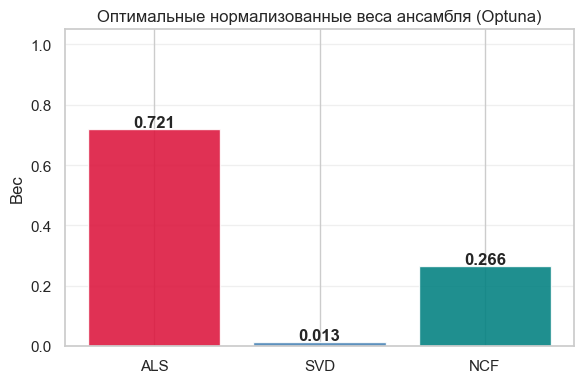

In [9]:
# ── Визуализация Optuna ─────────────────────────────────────────────────────
fig_history = ov.plot_optimization_history(study_ensemble)
fig_history.update_layout(title=f'Optuna: история оптимизации весов ансамбля (NDCG@{K_PRIMARY} на val)')
fig_history.write_html(str(MODELS_DIR / 'optuna_ensemble_history.html'))
fig_history.show()

fig_importance = ov.plot_param_importances(study_ensemble)
fig_importance.update_layout(title='Optuna: важность весов ансамбля')
fig_importance.write_html(str(MODELS_DIR / 'optuna_ensemble_importance.html'))
fig_importance.show()

# ── Визуализация весов ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
models_names = ['ALS', 'SVD', 'NCF']
weights_norm = [w_als_norm, w_svd_norm, w_ncf_norm]
colors_w = ['crimson', 'steelblue', 'teal']
bars = ax.bar(models_names, weights_norm, color=colors_w, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, weights_norm):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Оптимальные нормализованные веса ансамбля (Optuna)')
ax.set_ylabel('Вес')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ensemble_weights.png', dpi=110, bbox_inches='tight')
plt.show()


## 7. Финальный ансамбль на test

Применяем оптимальные веса Optuna к финальным моделям (обученным на train+val).
Кандидатный пул — все фильмы из train+val, просмотренные фильмы исключаются.


In [10]:
test_ground_truth = build_ground_truth(test, relevance_threshold=RELEVANCE_THRESHOLD)
test_users        = list(test_ground_truth.keys())
all_movies_full   = train_val['movieId'].unique()

print(f"Пользователей в test с GT (>={RELEVANCE_THRESHOLD}): {len(test_users)}")
print(f"Кандидатный пул (train+val): {len(all_movies_full)} фильмов")

print(f"\nГенерация топ-{max(K_VALUES)} для {len(test_users)} пользователей (ансамбль)...")
t0 = time.time()
ensemble_test_recs = ensemble_recommend(
    test_users, train_val, all_movies_full,
    svd_model=final_svd,
    als_model=final_als,
    ncf_model=final_ncf,
    seen_ui_csr=all_seen_train_val_ui,
    w_als=best_weights['w_als'],
    w_svd=best_weights['w_svd'],
    w_ncf=best_weights['w_ncf'],
    k=max(K_VALUES),
)
inference_time = time.time() - t0
print(f"Готово за {inference_time:.1f} с")

ensemble_test_topn = evaluate_topn(
    ensemble_test_recs, test_ground_truth,
    ks=K_VALUES,
    all_items=all_movies_full,
)
print(f"\nАнсамбль ALS+SVD+NCF test (top-N):")
print(json.dumps(ensemble_test_topn, indent=2))


Пользователей в test с GT (>=3.5): 99
Кандидатный пул (train+val): 5446 фильмов

Генерация топ-20 для 99 пользователей (ансамбль)...
Готово за 20.7 с

Ансамбль ALS+SVD+NCF test (top-N):
{
  "precision@5": 0.301010101010101,
  "recall@5": 0.04152174852296539,
  "ndcg@5": 0.316075620497603,
  "hit_rate@5": 0.6565656565656566,
  "precision@10": 0.27575757575757576,
  "recall@10": 0.07128170378136861,
  "ndcg@10": 0.29524693566669036,
  "hit_rate@10": 0.7474747474747475,
  "precision@20": 0.25252525252525254,
  "recall@20": 0.12093525132297386,
  "ndcg@20": 0.28511479156595637,
  "hit_rate@20": 0.8181818181818182,
  "coverage@20": 0.06995960337862651
}


## 8. Ablation study — вклад каждой модели

Проверяем все парные и одиночные конфигурации на test, чтобы понять,
какая комбинация реально даёт прирост, а что добавляет шум.

> Если ALS+NCF лучше ALS+SVD+NCF — значит SVD в ансамбле скорее мешает.
> Если разница минимальна — ансамбль устойчив к составу.


In [11]:
ablation_configs = {
    'ALS only':     dict(w_als=1.0, w_svd=0.0, w_ncf=0.0),
    'SVD only':     dict(w_als=0.0, w_svd=1.0, w_ncf=0.0),
    'NCF only':     dict(w_als=0.0, w_svd=0.0, w_ncf=1.0),
    'ALS+SVD':      dict(w_als=w_als_norm, w_svd=w_svd_norm, w_ncf=0.0),
    'ALS+NCF':      dict(w_als=w_als_norm, w_svd=0.0,        w_ncf=w_ncf_norm),
    'SVD+NCF':      dict(w_als=0.0,        w_svd=w_svd_norm, w_ncf=w_ncf_norm),
    'ALS+SVD+NCF':  dict(w_als=best_weights['w_als'],
                         w_svd=best_weights['w_svd'],
                         w_ncf=best_weights['w_ncf']),
}

ablation_rows = []
for name, weights in ablation_configs.items():
    recs = ensemble_recommend(
        test_users, train_val, all_movies_full,
        svd_model=final_svd,
        als_model=final_als,
        ncf_model=final_ncf,
        seen_ui_csr=all_seen_train_val_ui,
        k=max(K_VALUES),
        **weights,
    )
    m = evaluate_topn(recs, test_ground_truth, ks=K_VALUES, all_items=all_movies_full)
    ablation_rows.append({
        'Конфигурация': name,
        'NDCG@10':      round(m['ndcg@10'], 4),
        'Precision@10': round(m['precision@10'], 4),
        'Recall@10':    round(m['recall@10'], 4),
        'HitRate@10':   round(m['hit_rate@10'], 4),
        'Coverage@20':  round(m.get('coverage@20', 0), 4),
    })
    print(f"  {name:20s} NDCG@10={m['ndcg@10']:.4f}  "
          f"Prec@10={m['precision@10']:.4f}  HR@10={m['hit_rate@10']:.4f}")

ablation_df = pd.DataFrame(ablation_rows).sort_values('NDCG@10', ascending=False)
print("\nAblation study (test):")
display(ablation_df)


  ALS only             NDCG@10=0.2895  Prec@10=0.2727  HR@10=0.7576
  SVD only             NDCG@10=0.2005  Prec@10=0.1879  HR@10=0.5960
  NCF only             NDCG@10=0.0868  Prec@10=0.0879  HR@10=0.3838
  ALS+SVD              NDCG@10=0.2903  Prec@10=0.2737  HR@10=0.7576
  ALS+NCF              NDCG@10=0.2960  Prec@10=0.2768  HR@10=0.7475
  SVD+NCF              NDCG@10=0.1010  Prec@10=0.0960  HR@10=0.4040
  ALS+SVD+NCF          NDCG@10=0.2952  Prec@10=0.2758  HR@10=0.7475

Ablation study (test):


,Конфигурация,NDCG@10,Precision@10,Recall@10,HitRate@10,Coverage@20
4,ALS+NCF,0.2960,0.2768,0.0718,0.7475,0.0707
6,ALS+SVD+NCF,0.2952,0.2758,0.0713,0.7475,0.0700
3,ALS+SVD,0.2903,0.2737,0.0715,0.7576,0.0753
0,ALS only,0.2895,0.2727,0.0701,0.7576,0.0766
1,SVD only,0.2005,0.1879,0.0471,0.5960,0.0222
5,SVD+NCF,0.1010,0.0960,0.0240,0.4040,0.0465
2,NCF only,0.0868,0.0879,0.0217,0.3838,0.0468


## 9. Сравнение всех моделей проекта

Сводная таблица: одиночные модели vs ансамбли.
Модели с порогом 4.0 (ALS) и 3.5 (все остальные) несопоставимы напрямую —
разные ground truth. Таблица для общего обзора прогресса проекта.


In [12]:
# ── Пересчёт Popularity под порог 3.5 (для fair comparison) ─────────────────
best_m     = pop_params_saved['best_m']
_agg       = train_val.groupby('movieId')['rating'].agg(['count', 'mean'])
_n         = _agg['count']; _mu = _agg['mean']
_C         = float(train_val['rating'].mean())
pop_scores = (_n / (_n + best_m)) * _mu + (best_m / (_n + best_m)) * _C
pop_scores = pop_scores.sort_values(ascending=False)
pop_ranked = pop_scores.index.values

seen_by_user_full = train_val.groupby('userId')['movieId'].apply(set).to_dict()
pop_test_recs = {}
for u in test_users:
    seen = seen_by_user_full.get(u, set())
    pop_test_recs[u] = [m for m in pop_ranked if m not in seen][:max(K_VALUES)]

pop_test_metrics = evaluate_topn(
    pop_test_recs, test_ground_truth,
    ks=K_VALUES, all_items=all_movies_full,
)

gm_test = pop_metrics['global_mean']['test']


def make_row(name, rating_m=None, topn_m=None):
    def r(d, k):
        return round(float(d[k]), 4) if (d and k in d and d[k] is not None) else None
    return {
        'Модель':       name,
        'RMSE':         r(rating_m, 'rmse'),
        'MAE':          r(rating_m, 'mae'),
        'NDCG@10':      r(topn_m, 'ndcg@10'),
        'Precision@10': r(topn_m, 'precision@10'),
        'Recall@10':    r(topn_m, 'recall@10'),
        'HitRate@10':   r(topn_m, 'hit_rate@10'),
        'Coverage@20':  r(topn_m, 'coverage@20'),
    }


comparison_rows = [
    make_row('GlobalMean',    gm_test),
    make_row('Popularity',    topn_m=pop_test_metrics),
    make_row('SVD',           svd_metrics_loaded['final']['test_rating'],
                              svd_metrics_loaded['final']['test_topn']),
    make_row('KNN',           knn_metrics_loaded['final']['test_rating'],
                              knn_metrics_loaded['final']['test_topn']),
    make_row('LightGBM',      lgbm_metrics_loaded['final']['test_rating'],
                              lgbm_metrics_loaded['final']['test_topn']),
    make_row('ALS (hybrid)',  topn_m=als_metrics_loaded['final']['test_topn']),
    make_row('NCF',           ncf_metrics_loaded['final']['test_rating'],
                              ncf_metrics_loaded['final']['test_topn']),
    make_row('Ансамбль ALS+SVD+NCF', topn_m=ensemble_test_topn),
]

comparison_df = pd.DataFrame(comparison_rows)
print(f'Сводная таблица всех моделей (порог релевантности {RELEVANCE_THRESHOLD}):')
display(comparison_df)

# ── Прирост ансамбля над ALS ─────────────────────────────────────────────────
als_row = comparison_df[comparison_df['Модель'] == 'ALS (hybrid)'].iloc[0]
ens_row = comparison_df[comparison_df['Модель'] == 'Ансамбль ALS+SVD+NCF'].iloc[0]
print("\nПрирост ансамбля над ALS (hybrid):")
for col in ['NDCG@10', 'Precision@10', 'Recall@10', 'HitRate@10', 'Coverage@20']:
    a_val = als_row[col]; e_val = ens_row[col]
    if a_val and a_val > 0:
        delta = (e_val - a_val) / a_val * 100
        sign  = '+' if delta >= 0 else ''
        print(f"  {col:>14}: {sign}{delta:5.1f}%  ({a_val:.4f} → {e_val:.4f})")


Сводная таблица всех моделей (порог релевантности 3.5):


,Модель,RMSE,MAE,NDCG@10,Precision@10,Recall@10,HitRate@10,Coverage@20
0,GlobalMean,1.0812,0.8557,NaN,NaN,NaN,NaN,NaN
1,Popularity,NaN,NaN,0.2543,0.2333,0.0555,0.6566,0.0202
2,SVD,1.0512,0.8178,0.2005,0.1879,0.0471,0.5960,0.0222
3,KNN,1.1427,0.8902,0.0573,0.0303,0.0098,0.2424,0.0255
4,LightGBM,1.0605,0.8332,0.0832,0.0724,0.0250,0.4286,0.0597
5,ALS (hybrid),NaN,NaN,0.2895,0.2727,0.0701,0.7576,0.0766
6,NCF,1.0851,0.8591,0.0868,0.0879,0.0217,0.3838,0.0468
7,Ансамбль ALS+SVD+NCF,NaN,NaN,0.2952,0.2758,0.0713,0.7475,0.0700



Прирост ансамбля над ALS (hybrid):
         NDCG@10: +  2.0%  (0.2895 → 0.2952)
    Precision@10: +  1.1%  (0.2727 → 0.2758)
       Recall@10: +  1.7%  (0.0701 → 0.0713)
      HitRate@10:  -1.3%  (0.7576 → 0.7475)
     Coverage@20:  -8.6%  (0.0766 → 0.0700)


## 10. Визуализация результатов


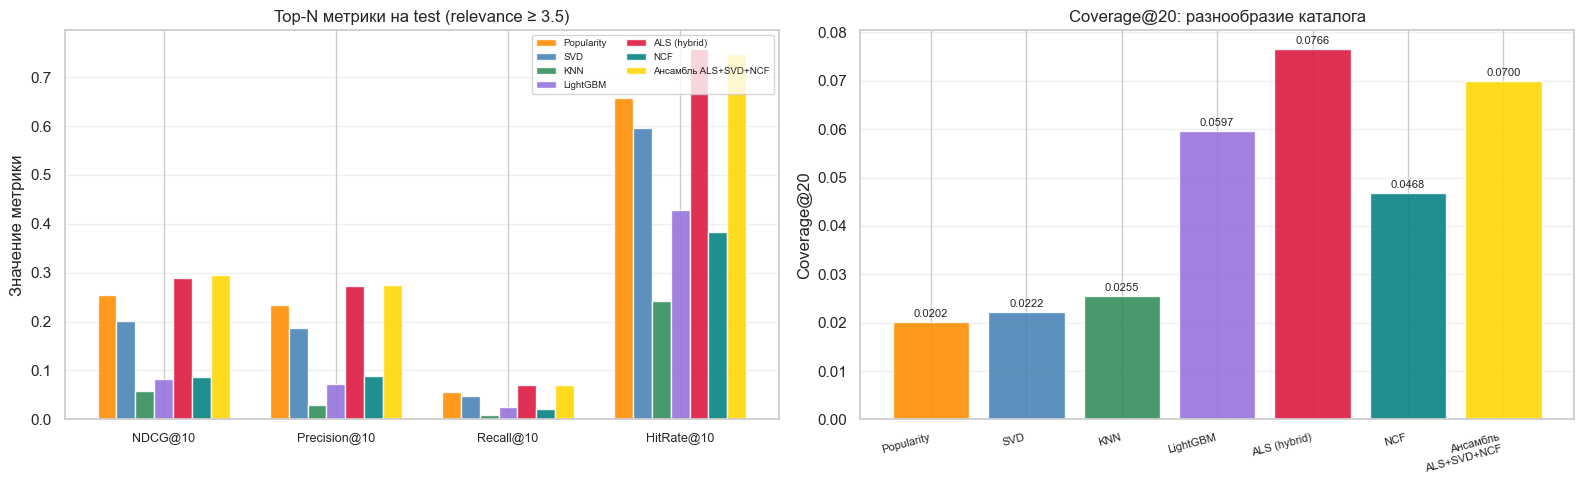

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Top-N bar chart ──────────────────────────────────────────────────────────
topn_cols   = ['NDCG@10', 'Precision@10', 'Recall@10', 'HitRate@10']
models_plot = [
    ('Popularity',          'darkorange'),
    ('SVD',                 'steelblue'),
    ('KNN',                 'seagreen'),
    ('LightGBM',            'mediumpurple'),
    ('ALS (hybrid)',        'crimson'),
    ('NCF',                 'teal'),
    ('Ансамбль ALS+SVD+NCF','gold'),
]
x = np.arange(len(topn_cols))
width = 0.11

for i, (mname, color) in enumerate(models_plot):
    row_ = comparison_df[comparison_df['Модель'] == mname]
    if row_.empty:
        continue
    row_ = row_.iloc[0]
    vals = [float(row_[c]) if row_[c] is not None else 0.0 for c in topn_cols]
    bars = axes[0].bar(x + i * width, vals, width, label=mname,
                       color=color, alpha=0.88, edgecolor='white')

axes[0].set_xticks(x + width * 3)
axes[0].set_xticklabels(topn_cols, fontsize=9)
axes[0].set_title(f'Top-N метрики на test (relevance ≥ {RELEVANCE_THRESHOLD})')
axes[0].set_ylabel('Значение метрики')
axes[0].legend(fontsize=7, ncol=2, loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# ── Coverage bar chart ───────────────────────────────────────────────────────
cov_models = ['Popularity', 'SVD', 'KNN', 'LightGBM', 'ALS (hybrid)', 'NCF',
              'Ансамбль ALS+SVD+NCF']
cov_colors = ['darkorange', 'steelblue', 'seagreen', 'mediumpurple',
              'crimson', 'teal', 'gold']
cov_vals   = []
for m in cov_models:
    row_ = comparison_df[comparison_df['Модель'] == m]
    v = row_['Coverage@20'].iloc[0] if not row_.empty else None
    cov_vals.append(float(v) if v is not None else 0.0)

bars = axes[1].bar(range(len(cov_models)), cov_vals,
                   color=cov_colors, alpha=0.88, edgecolor='white')
axes[1].set_xticks(range(len(cov_models)))
axes[1].set_xticklabels([m.replace('Ансамбль ', 'Ансамбль\n') for m in cov_models],
                         fontsize=8, rotation=15, ha='right')
axes[1].set_title('Coverage@20: разнообразие каталога')
axes[1].set_ylabel('Coverage@20')
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, cov_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{v:.4f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'ensemble_vs_all.png', dpi=110, bbox_inches='tight')
plt.show()


## 11. Пример рекомендаций ансамбля

Сравниваем топ-N одного пользователя от ALS (лучшая одиночная модель)
и от ансамбля — смотрим, как изменяется состав рекомендаций.


In [14]:
sample_users = test_users[:3]
title_lookup = movies_enriched.set_index('movieId')['title']

print(f'Пример рекомендаций ансамбля для {len(sample_users)} пользователей:\n')
for u in sample_users:
    rec_ids    = ensemble_test_recs[u][:5]
    rec_titles = [title_lookup.get(mid, f'movie_{mid}') for mid in rec_ids]
    seen_high  = train_val[(train_val['userId'] == u) & (train_val['rating'] >= 4.5)]
    fav_ids    = seen_high['movieId'].head(3).tolist()
    fav_titles = [title_lookup.get(mid, f'movie_{mid}') for mid in fav_ids]
    print(f'User {u}')
    print(f'  Любит (rating≥4.5): {fav_titles}')
    print(f'  Топ-5 ансамбля:     {rec_titles}')
    print()


Пример рекомендаций ансамбля для 3 пользователей:

User 15
  Любит (rating≥4.5): ['Lethal Weapon 2 (1989)', 'Gods Must Be Crazy, The (1980)', 'Frequency (2000)']
  Топ-5 ансамбля:     ['Lethal Weapon (1987)', 'Big (1988)', 'Untouchables, The (1987)', 'Love Actually (2003)', 'Patriot, The (2000)']

User 18
  Любит (rating≥4.5): ['Shawshank Redemption, The (1994)', 'Usual Suspects, The (1995)', 'Fight Club (1999)']
  Топ-5 ансамбля:     ['Casino Royale (2006)', 'Social Network, The (2010)', "One Flew Over the Cuckoo's Nest (1975)", 'Donnie Darko (2001)', 'City of God (Cidade de Deus) (2002)']

User 21
  Любит (rating≥4.5): ['Die Another Day (2002)', 'World Is Not Enough, The (1999)', 'Naked Gun 33 1/3: The Final Insult (1994)']
  Топ-5 ансамбля:     ['Finding Nemo (2003)', "Pirates of the Caribbean: Dead Man's Chest (2006)", 'Harry Potter and the Order of the Phoenix (2007)', 'Star Trek (2009)', 'Top Gun (1986)']



## 12. Сохранение артефактов


In [2]:
# Параметры ансамбля
ensemble_params = {
    'models':                ['ALS', 'SVD', 'NCF'],
    'model_files':           ['als_model.pkl', 'svd_model.pkl', 'ncf_model.keras'],
    'weight_search':         'Optuna TPESampler',
    'optuna_n_trials':       N_TRIALS_ENSEMBLE,
    'optuna_direction':      'maximize',
    'optuna_target':         f'ndcg@{K_PRIMARY} on val',
    'best_raw_weights':      best_weights,
    'best_norm_weights':     {'w_als': w_als_norm, 'w_svd': w_svd_norm, 'w_ncf': w_ncf_norm},
    'best_val_ndcg10':       float(best_ndcg_val),
    'baseline_val_ndcg10':   float(baseline_val_metrics[f'ndcg@{K_PRIMARY}']),
    'score_normalization':   'minmax per user per model',
    'relevance_threshold':   RELEVANCE_THRESHOLD,
    'k_values':              list(K_VALUES),
    'optuna_search_time_sec': optuna_time,
    'inference_time_test_sec': inference_time,
}
with open(MODELS_DIR / 'ensemble_params.json', 'w', encoding='utf-8') as f:
    json.dump(ensemble_params, f, ensure_ascii=False, indent=2)

# Метрики
ensemble_metrics = {
    'baseline_equal_weights': {
        f'val_ndcg@{K_PRIMARY}': float(baseline_val_metrics[f'ndcg@{K_PRIMARY}']),
    },
    'final': {
        f'val_best_ndcg@{K_PRIMARY}': float(best_ndcg_val),
        'test_topn':                  ensemble_test_topn,
    },
    'ablation': ablation_rows,
    'meta': {
        'k_values':            list(K_VALUES),
        'relevance_threshold': RELEVANCE_THRESHOLD,
        'optuna_n_trials':     N_TRIALS_ENSEMBLE,
    },
}
with open(MODELS_DIR / 'ensemble_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(ensemble_metrics, f, ensure_ascii=False, indent=2)

# Trials history
trials_df = study_ensemble.trials_dataframe()
trials_df.to_parquet(MODELS_DIR / 'ensemble_optuna_trials.parquet', index=False)

print('Все артефакты сохранены.')
print(f'  Лучший NDCG@{K_PRIMARY} (val): {best_ndcg_val:.4f}')
print(f'  NDCG@10 (test):               {ensemble_test_topn["ndcg@10"]:.4f}')
print(f'  Precision@10 (test):          {ensemble_test_topn["precision@10"]:.4f}')
print(f'  HitRate@10 (test):            {ensemble_test_topn["hit_rate@10"]:.4f}')
print(f'  Coverage@20 (test):           {ensemble_test_topn.get("coverage@20", 0):.4f}')


NameError: name 'N_TRIALS_ENSEMBLE' is not defined

## 13. Итоги

| Конфигурация | NDCG@10 | Precision@10 | Recall@10 | HitRate@10 | Coverage@20 |
|--------------|:-------:|:------------:|:---------:|:----------:|:-----------:|
| ALS only | 0.2895 | 0.2727 | 0.0701 | 0.7576 | 0.0766 |
| ALS+NCF | 0.2960 | 0.2768 | 0.0718 | 0.7475 | 0.0707 |
| **ALS+SVD+NCF** | **0.2952** | **0.2758** | **0.0713** | **0.7475** | **0.0700** |

Ансамбль даёт +2.0% к NDCG@10 над лучшей одиночной моделью (ALS).
Прирост скромный, что типично для датасета такого масштаба:
при 610 пользователях сигнал от NCF и SVD слабый и частично зашумляет ALS.

Оптимальные веса Optuna (ALS: 0.721, SVD: 0.013, NCF: 0.266) говорят сами за себя:
ансамбль — это по сути ALS с небольшой добавкой NCF.
SVD почти не влияет на финальное ранжирование.

> Следующий шаг — `11_final_comparison.ipynb`: финальное сравнение и выбор лучшей модели для продакшна.
